In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

sb.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7,5)
NAVY="#004BA0"
GOLD="#D1AB3E"

In [2]:
df=pd.read_csv("IPLPlayerStat.csv")
df.head()

,Unnamed: 0,player,runs,boundaries,balls_faced,wickets,balls_bowled,runs_conceded,matches,batting_avg,batting_strike_rate,boundaries_percent,bowling_economy,bowling_avg,bowling_strike_rate,catches,stumpings
0,0,A Ashish Reddy,280,31,196,18.0,270.0,400.0,28,10.00,142.86,15.82,8.89,22.22,15.00,8.0,0.0
1,1,A Badoni,161,18,139,2.0,12.0,12.0,11,14.64,115.83,12.95,6.00,6.00,6.00,8.0,0.0
2,2,A Chandila,4,0,7,11.0,234.0,245.0,12,0.33,57.14,0.00,6.28,22.27,21.27,2.0,0.0
3,3,A Chopra,53,7,75,0.0,0.0,0.0,6,8.83,70.67,9.33,0.00,0.00,0.00,2.0,0.0
4,4,A Choudhary,25,2,20,5.0,108.0,144.0,5,5.00,125.00,10.00,8.00,28.80,21.60,0.0,0.0


In [3]:
if "Unnamed: 0" in df.columns:
    df.drop("Unnamed: 0", axis=1, inplace=True)
print("shape",df.shape)
df.head()

shape (605, 16)


,player,runs,boundaries,balls_faced,wickets,balls_bowled,runs_conceded,matches,batting_avg,batting_strike_rate,boundaries_percent,bowling_economy,bowling_avg,bowling_strike_rate,catches,stumpings
0,A Ashish Reddy,280,31,196,18.0,270.0,400.0,28,10.00,142.86,15.82,8.89,22.22,15.00,8.0,0.0
1,A Badoni,161,18,139,2.0,12.0,12.0,11,14.64,115.83,12.95,6.00,6.00,6.00,8.0,0.0
2,A Chandila,4,0,7,11.0,234.0,245.0,12,0.33,57.14,0.00,6.28,22.27,21.27,2.0,0.0
3,A Chopra,53,7,75,0.0,0.0,0.0,6,8.83,70.67,9.33,0.00,0.00,0.00,2.0,0.0
4,A Choudhary,25,2,20,5.0,108.0,144.0,5,5.00,125.00,10.00,8.00,28.80,21.60,0.0,0.0


In [5]:
df["balls_faced"].describe()

count     605.000000
mean      373.477686
std       764.432561
min         1.000000
25%        18.000000
50%        73.000000
75%       285.000000
max      5266.000000
Name: balls_faced, dtype: float64

In [6]:
print(df.isnull().sum())

player                 0
runs                   0
boundaries             0
balls_faced            0
wickets                0
balls_bowled           0
runs_conceded          0
matches                0
batting_avg            0
batting_strike_rate    0
boundaries_percent     0
bowling_economy        0
bowling_avg            0
bowling_strike_rate    0
catches                0
stumpings              0
dtype: int64


In [13]:
x=df[["balls_faced"]]
y=df["runs"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model=LinearRegression()
model.fit(x_train,y_train)
print("intercept",model.intercept_)
print("coefficients",model.coef_[0])
print(f"every extra ball faced add {model.coef_[0]:.2f} runs on average")

intercept -15.330465838412863
coefficients 1.284369828647767
every extra ball faced add 1.28 runs on average


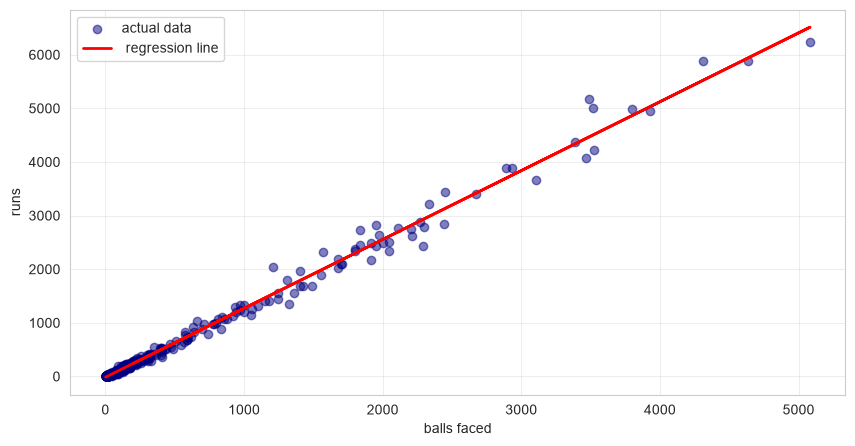

In [17]:
plt.figure(figsize=(10,5))
plt.scatter(x_train,y_train,color="navy",alpha=0.5,label="actual data")
plt.plot(x_train,model.predict(x_train),color="red",label=" regression line",linewidth=2)
#plt.plot(x_train,y_train,color="blue",label=" regression line",linewidth=2)
plt.xlabel("balls faced")
plt.ylabel("runs")
plt.legend()
plt.show()

In [19]:
y_pred=model.predict(x_test)
comparison=pd.DataFrame({
    "balls_faced":x_test["balls_faced"].values,
    "actual_runs":y_test.values,
    "predicted_runs":np.round(y_pred,1)
})
comparison.head(10)

,balls_faced,actual_runs,predicted_runs
0,434,522,542.1
1,27,40,19.3
2,57,76,57.9
3,31,21,24.5
4,552,663,693.6
5,865,985,1095.6
6,26,34,18.1
7,9,12,-3.8
8,18,20,7.8
9,703,920,887.6


In [20]:
new_player=pd.DataFrame({"balls_faced":[100,200,300]})
new_pred=model.predict(new_player)
for balls,runs in zip(new_player["balls_faced"],new_pred):
    print(f"balls faced: {balls} -> runs: {runs}")

balls faced: 100 -> runs: 113.10651702636383
balls faced: 200 -> runs: 241.54349989114053
balls faced: 300 -> runs: 369.9804827559172
